In [1]:
!pip3 install Pillow

In [2]:
from PIL import Image
from PIL.ExifTags import TAGS

In [3]:
# path to the image or video
imagename = "/content/00X22G508N.jpg"

# read the image data using PIL
image = Image.open(imagename)

In [4]:
info_dict = {
    "Filename": image.filename,
    "Image Size": image.size,
    "Image Height": image.height,
    "Image Width": image.width,
    "Image Format": image.format,
    "Image Mode": image.mode,
    "Image is Animated": getattr(image, "is_animated", False),
    "Frames in Image": getattr(image, "n_frames", 1)
}

for label,value in info_dict.items():
    print(f"{label:25}: {value}")

Filename                 : /content/00X22G508N.jpg
Image Size               : (1024, 1024)
Image Height             : 1024
Image Width              : 1024
Image Format             : JPEG
Image Mode               : RGB
Image is Animated        : False
Frames in Image          : 1


In [5]:
# extract EXIF data
exifdata = image.getexif()

In [7]:
for tag_id in exifdata:
    # get the tag name, instead of human unreadable tag id
    tag = TAGS.get(tag_id, tag_id)
    data = exifdata.get(tag_id)
    # decode bytes
    if isinstance(data, bytes):
        data = data.decode()
    print(f"{tag:25}: {data}")

In [10]:
infoDict = {} #Creating the dict to get the metadata tags
exifToolPath = 'D:/ExifTool/exifTool.exe' #for Windows user have to specify the Exif tool exe path for metadata extraction.
#For mac and linux user it is just
imgPath = '/content/00X22G508N.jpg'

process = subprocess.Popen([exifToolPath,imgPath],stdout=subprocess.PIPE, stderr=subprocess.STDOUT,universal_newlines=True)
''' get the tags in dict '''
for tag in process.stdout:
    line = tag.strip().split(':')
    infoDict[line[0].strip()] = line[-1].strip()

for k,v in infoDict.items():
    print(k,':', v)

NameError: name 'subprocess' is not defined

In [11]:
!pip install hachoir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.4/650.4 kB 8.7 MB/s eta 0:00:00


In [23]:
import subprocess

imgPath = '/content/IMG-20240226-WA0013.jpg'
exeProcess = "hachoir-metadata"
infoDict = {}

process = subprocess.Popen([exeProcess, imgPath],
                           stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                           universal_newlines=True)

for tag in process.stdout:
    line = tag.strip().split(':')
    if len(line) > 1:  # To avoid empty or invalid lines
        infoDict[line[0].strip()] = line[-1].strip()

for k, v in infoDict.items():
    print(k, ':', v)


Metadata : 
- Image width : 1280 pixels
- Image height : 720 pixels
- Bits/pixel : 24
- Pixel format : YCbCr
- Compression : JPEG (Progressive)
- Comment : 50%
- Format version : JFIF 1.01
- MIME type : image/jpeg
- Endianness : Big endian


In [22]:
from PIL import Image
from PIL.ExifTags import TAGS

# open the image
image = Image.open("/content/IMG-20240226-WA0013.jpg")

# extracting the exif metadata
exifdata = image.getexif()

# looping through all the tags present in exifdata
for tagid in exifdata:

    # getting the tag name instead of tag id
    tagname = TAGS.get(tagid, tagid)

    # passing the tagid to get its respective value
    value = exifdata.get(tagid)

    # printing the final result
    print(f"{tagname:25}: {value}")

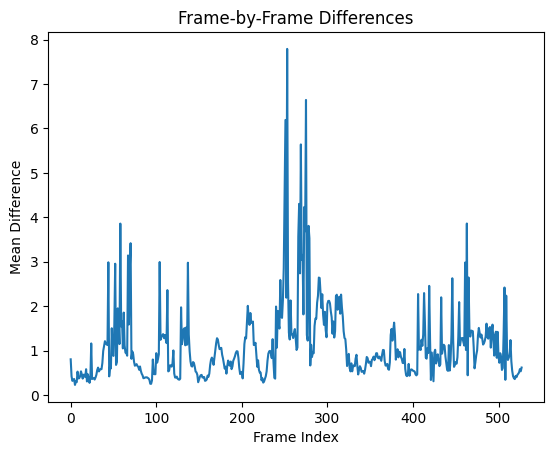

In [34]:

# Frame-by-Frame Analysis (Temporal Analysis)

import cv2
import numpy as np
import matplotlib.pyplot as plt

def frame_by_frame_analysis(video_path):
    cap = cv2.VideoCapture(video_path)
    prev_frame = None
    frame_differences = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert to grayscale for easier comparison
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_frame is not None:
            # Compute the absolute difference between consecutive frames
            diff = cv2.absdiff(prev_frame, gray_frame)
            diff_mean = np.mean(diff)
            frame_differences.append(diff_mean)

        prev_frame = gray_frame

    cap.release()

    # Plot differences across frames to visualize inconsistencies
    plt.plot(frame_differences)
    plt.title('Frame-by-Frame Differences')
    plt.xlabel('Frame Index')
    plt.ylabel('Mean Difference')
    plt.show()

# Example usage
frame_by_frame_analysis('/content/01_03__kitchen_still__JZUXXFRB.mp4')


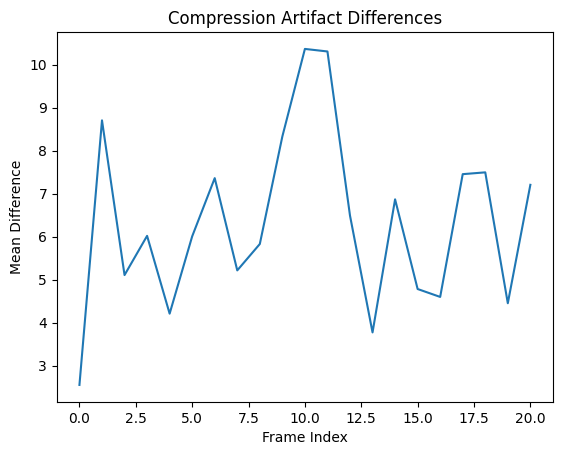

In [33]:
# Video Compression Forensics
import subprocess
import numpy as np
import cv2
import matplotlib.pyplot as plt

def video_compression_forensics(video_path):
    # Extract frames from the video using FFmpeg
    command = f"ffmpeg -i {video_path} -vf fps=1 frame_%04d.png"
    subprocess.run(command, shell=True)

    # Analyze the frames for compression artifacts
    frame_differences = []
    for i in range(1, 100):  # Example: analyze the first 100 frames
        frame_path = f'frame_{i:04d}.png'
        frame = cv2.imread(frame_path)
        if frame is None:
            break

        # Convert the frame to grayscale for artifact analysis
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Look for compression artifacts by calculating the mean pixel difference
        if i > 1:
            prev_frame = cv2.imread(f'frame_{i-1:04d}.png')
            prev_gray_frame = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
            diff = cv2.absdiff(gray_frame, prev_gray_frame)
            diff_mean = np.mean(diff)
            frame_differences.append(diff_mean)

    # Plot the differences to see any irregularities
    plt.plot(frame_differences)
    plt.title('Compression Artifact Differences')
    plt.xlabel('Frame Index')
    plt.ylabel('Mean Difference')
    plt.show()

# Example usage
video_compression_forensics('/content/01_03__kitchen_still__JZUXXFRB.mp4')


In [32]:
from moviepy.editor import VideoFileClip
import numpy as np

def audio_visual_sync_detection(video_path):
    # Load the video file
    video_clip = VideoFileClip(video_path)

    # Extract audio from the video
    audio_clip = video_clip.audio
    audio_samples = audio_clip.to_soundarray(fps=22000)

    # Calculate the mean intensity of audio samples over time (simplified)
    audio_intensity = np.mean(np.abs(audio_samples), axis=1)

    # Extract frames for visual events (simple example: the first 10 frames)
    frame_intensity = []
    for i, frame in enumerate(video_clip.iter_frames(fps=24, dtype='uint8')):
        if i > 10:
            break
        # Calculate the average intensity of each frame (simplified)
        frame_intensity.append(np.mean(frame))

    # Compare the audio intensity with the video frame intensity for sync issues
    plt.plot(audio_intensity[:len(frame_intensity)], label='Audio Intensity')
    plt.plot(frame_intensity, label='Frame Intensity')
    plt.legend()
    plt.title('Audio-Visual Sync Detection')
    plt.show()

# Example usage
audio_visual_sync_detection('/content/01_03__kitchen_still__JZUXXFRB.mp4')


AttributeError: 'NoneType' object has no attribute 'to_soundarray'

In [31]:
import cv2
import numpy as np

def watermark_detection(video_path, watermark_pattern_path):
    # Load video and watermark pattern
    cap = cv2.VideoCapture(video_path)
    watermark_pattern = cv2.imread(watermark_pattern_path, 0)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to grayscale for easier processing
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Use template matching to find watermark pattern
        result = cv2.matchTemplate(gray_frame, watermark_pattern, cv2.TM_CCOEFF_NORMED)
        _, max_val, _, max_loc = cv2.minMaxLoc(result)

        # If watermark is detected above a threshold
        if max_val > 0.8:
            print(f"Watermark detected at location: {max_loc}")
            break

    cap.release()

# Example usage
watermark_detection('/content/01_03__kitchen_still__JZUXXFRB.mp4', 'watermark_pattern.png')


error: OpenCV(4.10.0) /io/opencv/modules/imgproc/src/templmatch.cpp:587: error: (-215:Assertion failed) corr.rows <= img.rows + templ.rows - 1 && corr.cols <= img.cols + templ.cols - 1 in function 'crossCorr'


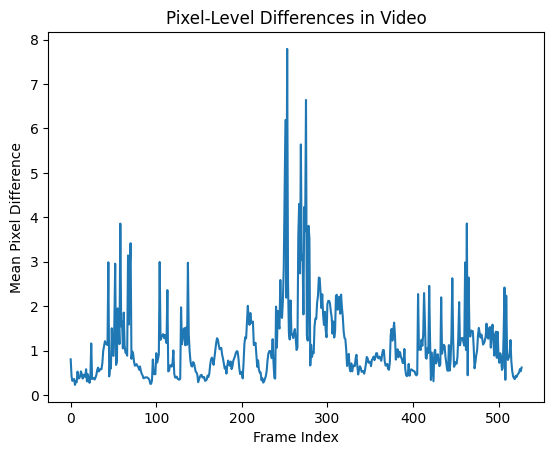

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def deep_pixel_analysis(video_path):
    cap = cv2.VideoCapture(video_path)
    prev_frame = None
    pixel_differences = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Convert frame to grayscale
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if prev_frame is not None:
            # Compute absolute difference at the pixel level
            diff = cv2.absdiff(prev_frame, gray_frame)
            pixel_diff_mean = np.mean(diff)
            pixel_differences.append(pixel_diff_mean)

        prev_frame = gray_frame

    cap.release()

    # Plot pixel-level differences
    plt.plot(pixel_differences)
    plt.title('Pixel-Level Differences in Video')
    plt.xlabel('Frame Index')
    plt.ylabel('Mean Pixel Difference')
    plt.show()

# Example usage
deep_pixel_analysis('/content/01_03__kitchen_still__JZUXXFRB.mp4')
